#📌 Importar, cargar y explorar los datos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

data = requests.get(url).json()

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [4]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


#📌 Limpieza de datos

In [6]:
df = df.drop_duplicates()

In [7]:
df["Churn"] = df["Churn"].replace({
    "Yes":1,
    "No":0
})

In [10]:
print(df.columns.tolist())

['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [11]:
df.columns = df.columns.str.replace(".", "_", regex=False)
print(df.columns.tolist())

['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges_Monthly', 'account_Charges_Total']


In [12]:
df["Churn"] = df["Churn"].replace({
    "Yes": 1,
    "No": 0
})

In [13]:
binary_cols = [
    "customer_Partner",
    "customer_Dependents",
    "phone_PhoneService",
    "account_PaperlessBilling"
]

for col in binary_cols:
    df[col] = df[col].replace({
        "Yes": 1,
        "No": 0
    })

/tmp/ipykernel_666/608513870.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [14]:
# Limpiar nombres de columnas
df.columns = df.columns.str.replace(".", "_", regex=False)

# Eliminar duplicados
df = df.drop_duplicates()

# Convertir Churn a valores binarios
df["Churn"] = df["Churn"].replace({
    "Yes": 1,
    "No": 0
})

# Convertir variables binarias
binary_cols = [
    "customer_Partner",
    "customer_Dependents",
    "phone_PhoneService",
    "account_PaperlessBilling"
]

for col in binary_cols:
    df[col] = df[col].replace({
        "Yes": 1,
        "No": 0
    })

print(df.head())
print(df.info())

   customerID Churn customer_gender  customer_SeniorCitizen  customer_Partner  \
0  0002-ORFBO     0          Female                       0                 1   
1  0003-MKNFE     0            Male                       0                 0   
2  0004-TLHLJ     1            Male                       0                 0   
3  0011-IGKFF     1            Male                       1                 1   
4  0013-EXCHZ     1          Female                       1                 1   

   customer_Dependents  customer_tenure  phone_PhoneService  \
0                    1                9                   1   
1                    0                9                   1   
2                    0                4                   1   
3                    0               13                   1   
4                    0                3                   1   

  phone_MultipleLines internet_InternetService  ... internet_OnlineBackup  \
0                  No                      DSL  ...      

#🔧 Distribución

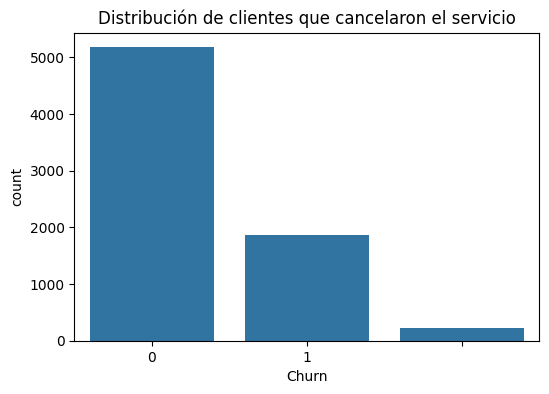

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Distribución de clientes que cancelaron el servicio")
plt.show()

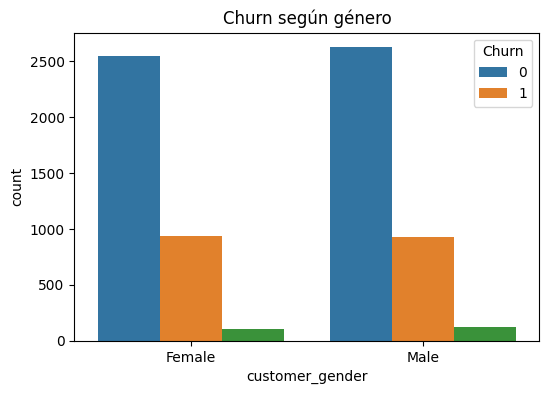

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="customer_gender", hue="Churn")
plt.title("Churn según género")
plt.show()

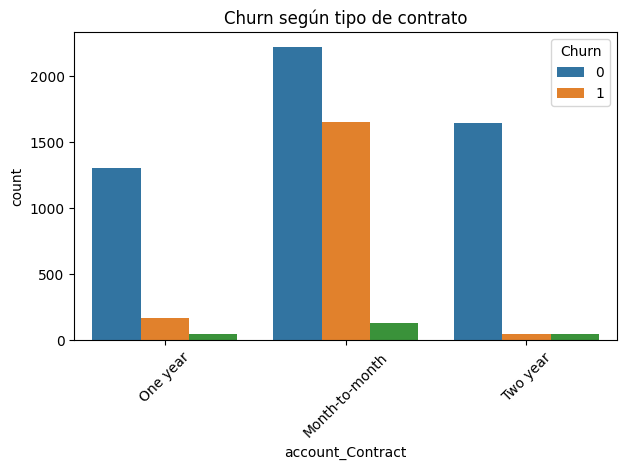

In [17]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="account_Contract", hue="Churn")
plt.title("Churn según tipo de contrato")
plt.xticks(rotation=45)
plt.show()

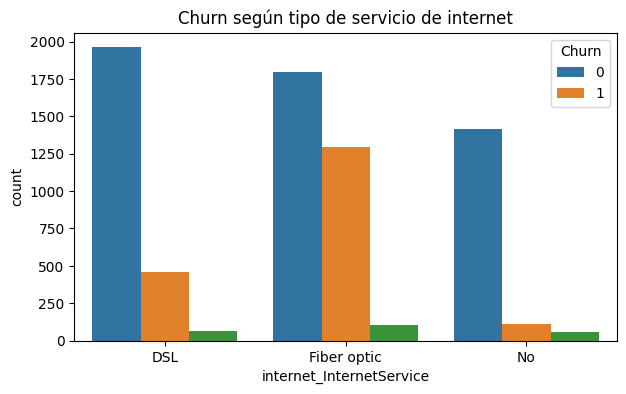

In [18]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="internet_InternetService", hue="Churn")
plt.title("Churn según tipo de servicio de internet")
plt.show()

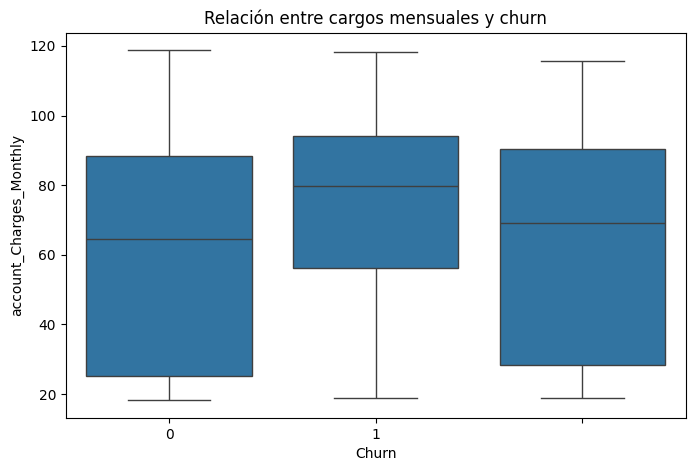

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="account_Charges_Monthly")
plt.title("Relación entre cargos mensuales y churn")
plt.show()

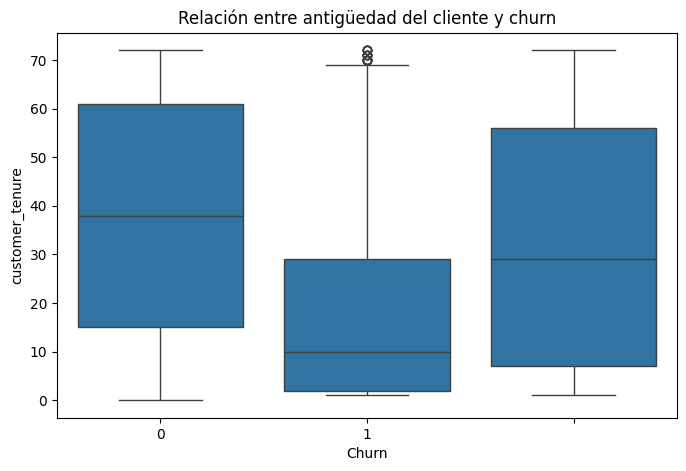

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="customer_tenure")
plt.title("Relación entre antigüedad del cliente y churn")
plt.show()

#📊 Carga y análisis

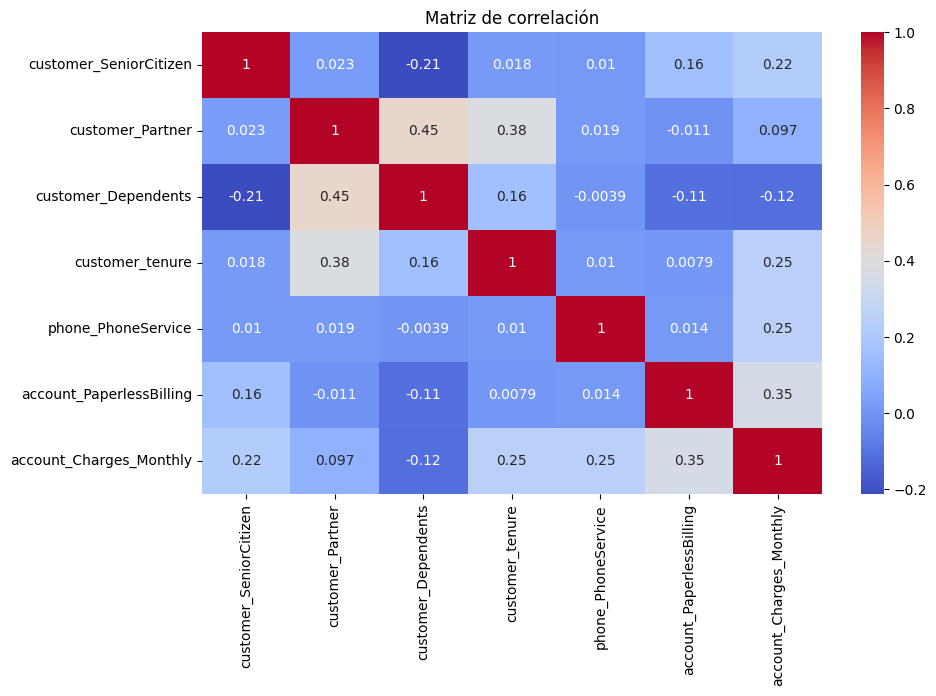

In [21]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

In [23]:
# Limpiar y convertir Churn correctamente
df["Churn"] = df["Churn"].replace({
    "Yes": 1,
    "No": 0,
    "yes": 1,
    "no": 0
})

# Convertir a numérico por seguridad
df["Churn"] = pd.to_numeric(df["Churn"], errors="coerce")

# Verificar valores únicos
print(df["Churn"].unique())

[ 0.  1. nan]


In [24]:
churn_rate = df["Churn"].mean() * 100

print(f"Tasa de cancelación de clientes: {churn_rate:.2f}%")

Tasa de cancelación de clientes: 26.54%


#📄Informe final

# 📊 Informe Final – Análisis de Evasión de Clientes (Churn)

## Introducción

Telecom X enfrenta un problema importante de evasión de clientes (churn), lo que significa que una parte significativa de sus usuarios decide cancelar sus servicios. Comprender las razones detrás de esta cancelación es fundamental para que la empresa pueda desarrollar estrategias que permitan mejorar la retención de clientes.

El objetivo de este análisis fue explorar los datos de clientes de Telecom X para identificar patrones y factores asociados con la cancelación del servicio. Para ello se aplicaron procesos de extracción, limpieza y análisis exploratorio de datos utilizando Python, Pandas y herramientas de visualización.

---

## Limpieza y Tratamiento de Datos

Los datos fueron obtenidos desde una API en formato JSON y posteriormente convertidos en un DataFrame de Pandas para facilitar su análisis.

Durante el proceso de preparación de los datos se realizaron las siguientes acciones:

- Normalización de la estructura del JSON para convertirlo en un DataFrame.
- Limpieza de nombres de columnas para facilitar su manipulación.
- Conversión de variables categóricas como **Yes/No** a valores binarios **1 y 0**.
- Conversión de variables numéricas que estaban almacenadas como texto.
- Eliminación de duplicados y revisión de valores nulos.

Estos pasos permitieron garantizar que los datos estuvieran listos para el análisis exploratorio.

---

## Análisis Exploratorio de Datos (EDA)

### Distribución de Churn

El análisis muestra que aproximadamente **26.54% de los clientes cancelaron el servicio**, mientras que la mayoría continúa utilizando los servicios de la empresa.

Esto indica que, aunque la mayoría de los clientes se mantiene, la tasa de cancelación sigue siendo significativa y puede representar un impacto importante en los ingresos de la empresa.

---

### Churn según género

El análisis por género muestra que la cancelación del servicio se distribuye de manera bastante similar entre hombres y mujeres. Esto sugiere que el género no es un factor determinante en la decisión de cancelar el servicio.

---

### Churn según tipo de contrato

El tipo de contrato muestra diferencias claras en la tasa de cancelación.

Los clientes con contratos **mes a mes (Month-to-month)** presentan una tasa de churn significativamente mayor en comparación con aquellos que tienen contratos de **uno o dos años**.

Esto sugiere que los contratos a largo plazo ayudan a retener a los clientes.

---

### Churn según tipo de servicio de internet

Los clientes que utilizan **internet de fibra óptica** presentan una mayor proporción de cancelaciones en comparación con los usuarios de DSL o aquellos que no tienen servicio de internet.

Esto podría indicar problemas relacionados con la calidad del servicio, el precio o las expectativas del cliente.

---

### Relación entre cargos mensuales y churn

El análisis de los cargos mensuales muestra que los clientes que cancelan el servicio tienden a tener **costos mensuales más altos** en comparación con aquellos que permanecen en la empresa.

Esto sugiere que el precio puede ser un factor importante en la decisión de cancelar el servicio.

---

### Relación entre antigüedad del cliente y churn

Los clientes que han permanecido menos tiempo en la empresa tienen una mayor probabilidad de cancelar el servicio.

Por el contrario, los clientes con mayor antigüedad tienden a mantenerse más tiempo en la compañía.

Esto indica que los primeros meses de relación con el cliente son críticos para la retención.

---

### Análisis de correlación

La matriz de correlación muestra algunas relaciones importantes entre las variables.

Se observa una correlación moderada entre:

- **tenure (antigüedad del cliente)**
- **charges monthly (cargos mensuales)**
- **paperless billing**

Estas variables pueden estar asociadas con la probabilidad de cancelación.

---

## Conclusiones e Insights

A partir del análisis realizado se pueden identificar varios factores asociados con la evasión de clientes:

- Los clientes con **contratos mes a mes** tienen mayor probabilidad de cancelar.
- Los clientes con **mayores cargos mensuales** tienden a abandonar el servicio con más frecuencia.
- Los clientes con **menor antigüedad** presentan mayor riesgo de churn.
- El **tipo de servicio de internet (fibra óptica)** muestra mayor tasa de cancelación.

Estos factores pueden ayudar a la empresa a identificar clientes con mayor riesgo de abandono.

---

## Recomendaciones

Con base en los resultados obtenidos, se sugieren las siguientes estrategias para reducir la evasión de clientes:

- Incentivar contratos de **largo plazo** mediante descuentos o beneficios.
- Analizar el servicio de **internet de fibra óptica** para identificar posibles problemas de calidad o precio.
- Diseñar programas de **retención para nuevos clientes** durante los primeros meses.
- Ofrecer **planes más flexibles o personalizados** para clientes con cargos mensuales elevados.

Implementar estas estrategias puede ayudar a Telecom X a mejorar la retención de clientes y reducir la tasa de churn en el futuro.